# Telecom Customer Churn Prediction Using Machine Learning

## Project Overview

This project develops a machine learning solution to predict customer churn for a telecommunications company.

The project includes data preprocessing, categorical feature encoding, numerical feature scaling, exploratory analysis, train-test splitting, and machine learning model development.

Two classification models were implemented and evaluated:

- Random Forest Classifier
- Logistic Regression

The models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Feature importance analysis was also performed using the Random Forest model to identify the features that contribute most to churn prediction.

## Dataset

Telco Customer Churn dataset containing 7,043 customer records and customer service, contract, billing, and demographic information.

## Technologies Used

Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

## Step 1: Project Setup and Data Acquisition

This section sets up the Python environment and loads the Telco Customer Churn dataset for analysis.

## Step 2: Load and Initial Explore the Dataset

The dataset is loaded using Pandas and initial exploration is performed to understand its structure, data types, missing values, and churn distribution.

In [1]:
import pandas as pd

csv_file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(csv_file_path)

print("--- First 5 rows of the DataFrame: ---")
print(df.head())

print("\n--- DataFrame Info (Column types and non-null counts): ---")
print(df.info())

print("\n--- Basic Statistical Summary of Numeric Columns: ---")
print(df.describe())

print("\n--- Unique values in 'Churn' column (Our target variable): ---")
print(df['Churn'].value_counts())

--- First 5 rows of the DataFrame: ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streaming

## Step 3: Data Cleaning and Preprocessing

This is a critical step to prepare the raw data for machine learning. It involves:
- Handling missing values (specifically in 'TotalCharges').
- Correcting data types (converting 'TotalCharges' to numeric).
- Encoding categorical variables into numerical format suitable for models (using binary mapping and One-Hot Encoding).
- Removing irrelevant columns like 'customerID'.

In [2]:
import numpy as np

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df.drop('customerID', axis=1, inplace=True)

for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].replace({'No internet service': 'No'})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("--- DataFrame Info after cleaning and encoding: ---")
print(df.info())

print("\n--- First 5 rows of the processed DataFrame: ---")
print(df.head())

--- DataFrame Info after cleaning and encoding: ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_Yes              

## Step 4: Feature Scaling and Data Splitting

In this step, numerical features are scaled to standardize their range, which helps optimize model performance. The dataset is then split into training and testing sets to ensure an unbiased evaluation of the model's ability to generalize to unseen data. Stratified splitting is used to maintain the proportion of churners in both sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Shape of X_train (features for training): ---")
print(X_train.shape)
print("\n--- Shape of X_test (features for testing): ---")
print(X_test.shape)
print("\n--- Shape of y_train (target for training): ---")
print(y_train.shape)
print("\n--- Shape of y_test (target for testing): ---")
print(y_test.shape)

print("\n--- First 5 rows of X_train after scaling: ---")
print(X_train.head())

--- Shape of X_train (features for training): ---
(5634, 23)

--- Shape of X_test (features for testing): ---
(1409, 23)

--- Shape of y_train (target for training): ---
(5634,)

--- Shape of y_test (target for testing): ---
(1409,)

--- First 5 rows of X_train after scaling: ---
        gender  SeniorCitizen   Partner  Dependents    tenure  PhoneService  \
3738 -0.990532      -0.439916 -0.966622   -0.654012  0.107048     -3.054010   
3151 -0.990532      -0.439916  1.034530    1.529024 -0.707359      0.327438   
4860 -0.990532      -0.439916  1.034530    1.529024 -0.788800     -3.054010   
3867  1.009559      -0.439916  1.034530   -0.654012 -0.259435      0.327438   
3810 -0.990532      -0.439916  1.034530    1.529024 -1.277445      0.327438   

      PaperlessBilling  MonthlyCharges  TotalCharges  MultipleLines_Yes  ...  \
3738         -1.205113       -0.517207     -0.256176              False  ...   
3151         -1.205113        0.343603     -0.499034              False  ...   
4860

## Step 5: Model Training - Random Forest Classifier

A Random Forest Classifier, an ensemble machine learning model, is trained on the prepared training data. This model learns the complex patterns and relationships between customer features and their churn status.

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Step 6: Model Evaluation

The performance of the trained Random Forest model is rigorously evaluated using key metrics on the unseen test data. Metrics include Accuracy, Precision, Recall, F1-Score, and ROC AUC score, along with a Classification Report and Confusion Matrix, providing a comprehensive understanding of the model's predictive capability.

--- Model Evaluation ---
Accuracy: 0.7906
Precision: 0.6339
Recall: 0.5000
F1-Score: 0.5590
ROC AUC Score: 0.8300

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


--- Confusion Matrix ---


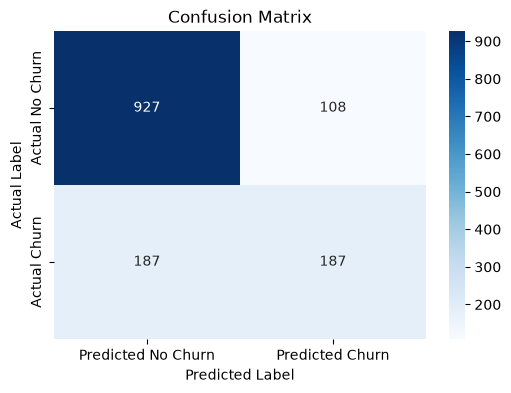

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 7: Feature Importance Analysis

This step identifies the most influential features that the Random Forest model used to predict customer churn. Understanding feature importance provides valuable business insights into what truly drives customer attrition, which can inform targeted retention strategies.

--- Top 10 Most Important Features: ---
TotalCharges                      0.191615
MonthlyCharges                    0.174860
tenure                            0.174704
InternetService_Fiber optic       0.049169
PaymentMethod_Electronic check    0.039228
Contract_Two year                 0.035199
gender                            0.028475
PaperlessBilling                  0.026382
OnlineSecurity_Yes                0.025073
Partner                           0.023340
dtype: float64


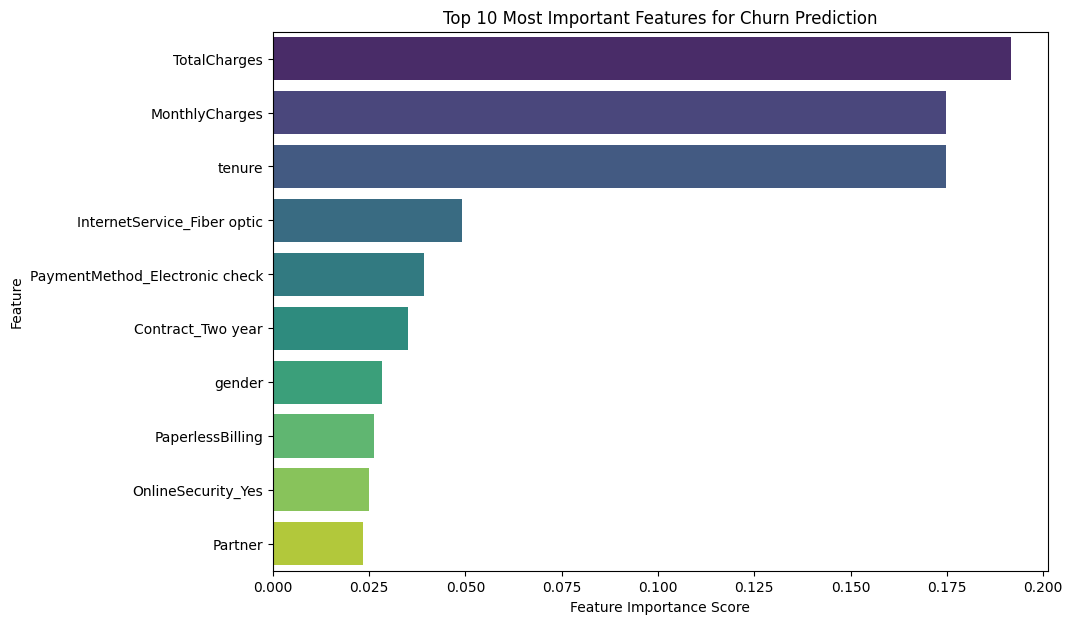

In [14]:
feature_importances = model.feature_importances_
features = X.columns
importance_df = pd.Series(feature_importances, index=features).sort_values(ascending=False)
print("--- Top 10 Most Important Features: ---")
print(importance_df.head(10))
plt.figure(figsize=(10, 7))
sns.barplot(x=importance_df.head(10).values, y=importance_df.head(10).index,
            palette='viridis', hue=importance_df.head(10).index, legend=False)
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Predictions
logistic_pred = logistic_model.predict(X_test)
logistic_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, logistic_pred):.4f}")
print(f"Precision: {precision_score(y_test, logistic_pred):.4f}")
print(f"Recall: {recall_score(y_test, logistic_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, logistic_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, logistic_pred_proba):.4f}")

=== Logistic Regression Evaluation ===
Accuracy: 0.8041
Precision: 0.6551
Recall: 0.5535
F1-Score: 0.6000
ROC AUC Score: 0.8423


In [9]:
# Compare model performance

import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, logistic_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, logistic_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, logistic_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, logistic_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, logistic_pred_proba)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.7906,0.6339,0.5000,0.559,0.8300
1,Logistic Regression,0.8041,0.6551,0.5535,0.600,0.8423


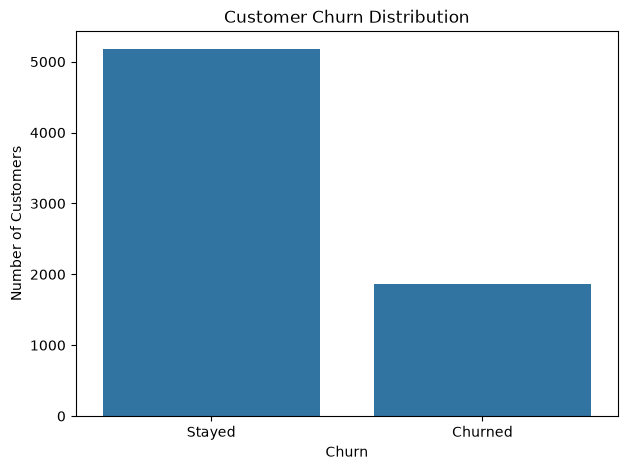

In [11]:
# EDA: Customer Churn Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [12]:
# Churn Percentage

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


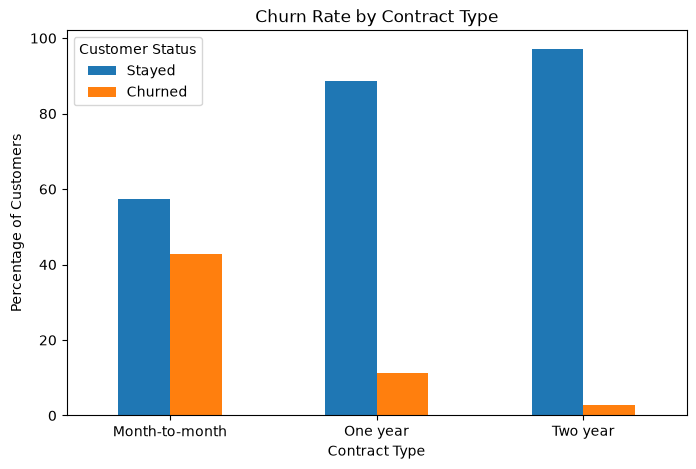

In [17]:


# EDA: Churn by Contract Type

df['Contract_Type'] = 'Month-to-month'

df.loc[df['Contract_One year'] == True, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == True, 'Contract_Type'] = 'Two year'

contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.columns = ['Stayed', 'Churned']

contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Customer Status')

plt.show()

In [16]:
df[['Churn', 'Contract_One year', 'Contract_Two year']].head()

,Churn,Contract_One year,Contract_Two year
0,0,False,False
1,0,True,False
2,1,False,False
3,0,True,False
4,1,False,False


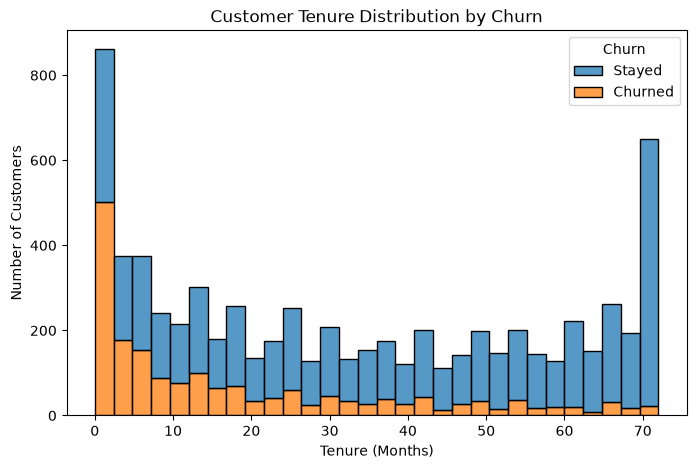

In [19]:
# EDA: Churn by Customer Tenure

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure',
    hue=df['Churn'].map({0: 'Stayed', 1: 'Churned'}),
    bins=30,
    multiple='stack'
)

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

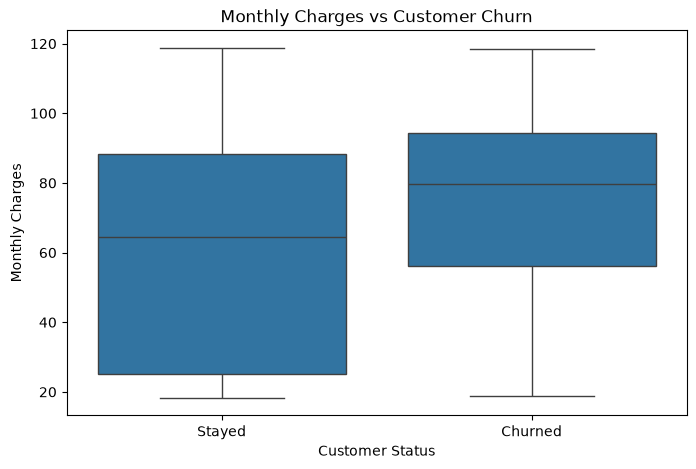

In [20]:
# EDA: Monthly Charges vs Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges')

plt.show()

In [21]:
# EDA: Churn by Payment Method

payment_churn = pd.crosstab(
    df['PaymentMethod_Credit card (automatic)'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,0,1
PaymentMethod_Credit card (automatic),,
False,70.349574,29.650426
True,84.756899,15.243101


In [22]:
df.columns[df.columns.str.startswith('PaymentMethod')]

Index(['PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [23]:
raw_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

payment_churn = pd.crosstab(
    raw_df['PaymentMethod'],
    raw_df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


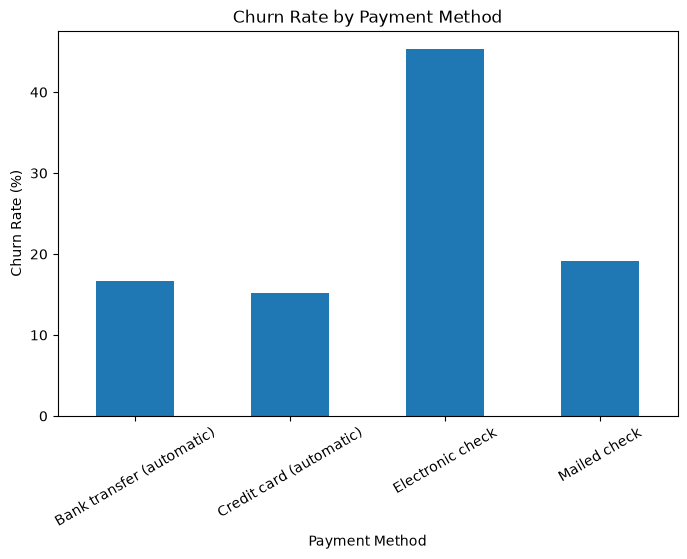

In [24]:
payment_churn['Yes'].plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)

plt.show()

In [25]:
contract_churn = pd.crosstab(
    raw_df['Contract'],
    raw_df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


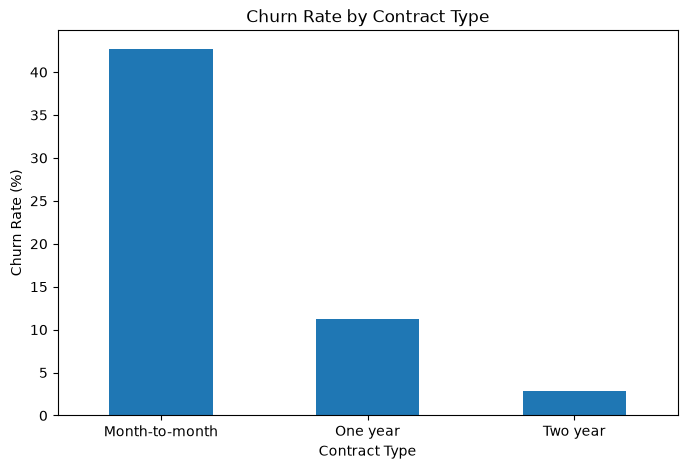

In [26]:
contract_churn['Yes'].plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

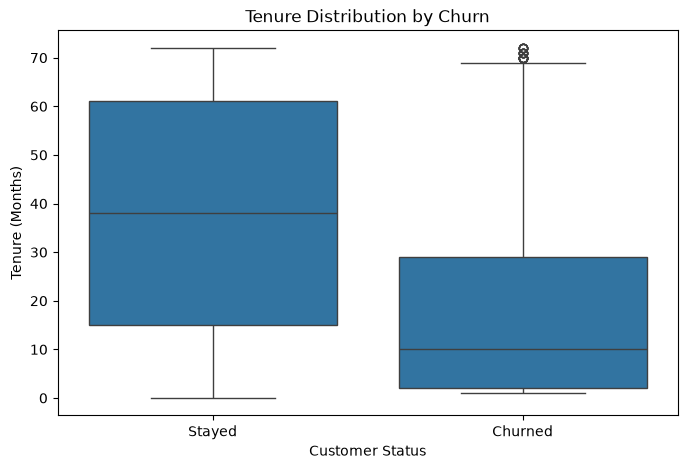

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=raw_df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Customer Status')
plt.ylabel('Tenure (Months)')

plt.xticks([0, 1], ['Stayed', 'Churned'])

plt.show()

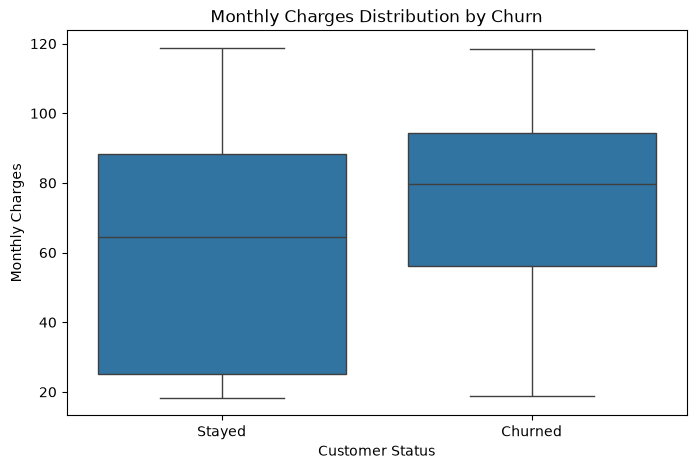

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=raw_df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges')

plt.xticks([0, 1], ['Stayed', 'Churned'])

plt.show()

In [29]:
gender_churn = pd.crosstab(
    raw_df['gender'],
    raw_df['Churn'],
    normalize='index'
) * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [30]:
senior_churn = pd.crosstab(
    raw_df['SeniorCitizen'],
    raw_df['Churn'],
    normalize='index'
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [31]:
internet_churn = pd.crosstab(
    raw_df['InternetService'],
    raw_df['Churn'],
    normalize='index'
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


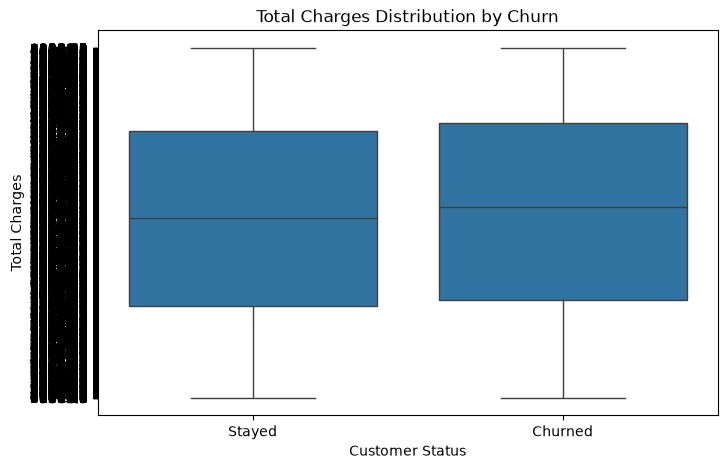

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=raw_df
)

plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Customer Status')
plt.ylabel('Total Charges')

plt.show()

In [33]:
raw_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
raw_df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [37]:
raw_df['TotalCharges'] = pd.to_numeric(
    raw_df['TotalCharges'],
    errors='coerce'
)

In [38]:
raw_df['TotalCharges'].isnull().sum()

np.int64(11)

In [39]:
raw_df = raw_df.dropna(subset=['TotalCharges'])

In [40]:
raw_df.shape

(7032, 21)

In [41]:
raw_df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [42]:
raw_df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [43]:
raw_df['Churn'] = raw_df['Churn'].map({'No': 0, 'Yes': 1})

In [44]:
raw_df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [45]:
raw_df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [46]:
X = raw_df.drop(['Churn', 'customerID'], axis=1)
y = raw_df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [47]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (7032, 19)
Encoded X shape: (7032, 30)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (5625, 30)
Scaled testing data: (1407, 30)


In [50]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=== Logistic Regression Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_test, logistic_pred):.4f}")
print(f"Precision: {precision_score(y_test, logistic_pred):.4f}")
print(f"Recall:    {recall_score(y_test, logistic_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, logistic_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, logistic_pred_proba):.4f}")

=== Logistic Regression Evaluation ===
Accuracy:  0.8038
Precision: 0.6476
Recall:    0.5749
F1-Score:  0.6091
ROC-AUC:   0.8357


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [53]:
print("=== Random Forest Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_pred_proba):.4f}")

=== Random Forest Evaluation ===
Accuracy:  0.7875
Precision: 0.6221
Recall:    0.5107
F1-Score:  0.5609
ROC-AUC:   0.8171


In [54]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, logistic_pred_proba),
        roc_auc_score(y_test, rf_pred_proba)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091,0.8357
1,Random Forest,0.7875,0.6221,0.5107,0.5609,0.8171


In [55]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191748
1,tenure,0.170417
2,MonthlyCharges,0.168513
10,InternetService_Fiber optic,0.039125
28,PaymentMethod_Electronic check,0.037528
25,Contract_Two year,0.030091
4,gender_Male,0.029122
13,OnlineSecurity_Yes,0.028514
26,PaperlessBilling_Yes,0.025664
19,TechSupport_Yes,0.024337


## Model Results

Two machine learning models were trained and evaluated on the Telco Customer Churn dataset.

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8038 | 0.6476 | 0.5749 | 0.6091 | 0.8357 |
| Random Forest | 0.7875 | 0.6221 | 0.5107 | 0.5609 | 0.8171 |

In this experiment, Logistic Regression achieved higher scores across the evaluation metrics on the test dataset.

Random Forest feature importance was also used to identify features that contributed most to the model's predictions. TotalCharges, MonthlyCharges, tenure, InternetService, and PaymentMethod were among the important features.